# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [30]:
# ==========================================
# 1. LIBRARY UNTUK MANIPULASI & ANALISIS DATA
# ==========================================
import pandas as pd
import numpy as np

# ==========================================
# 2. LIBRARY UNTUK VISUALISASI DATA (EDA)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# ==========================================
# 3. LIBRARY UNTUK TEXT PREPROCESSING (NLP)
# ==========================================
import re
import string
# Catatan: Jika nanti butuh Sastrawi untuk stemming Bahasa Indonesia,
# Anda perlu install dulu di cell terpisah pakai: !pip install Sastrawi

# ==========================================
# 4. LIBRARY MACHINE LEARNING & EVALUASI (Scikit-Learn)
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ==========================================
# 5. LIBRARY DEEP LEARNING (TensorFlow / Keras)
# ==========================================
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping

# Mengatur agar visualisasi matplotlib langsung muncul di notebook
%matplotlib inline

print("Pustaka berhasil diimpor! Siap melangkah ke tahap berikutnya.")

Pustaka berhasil diimpor! Siap melangkah ke tahap berikutnya.


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
# =================================================================
# TAHAP 3: MEMUAT DATASET (DATA LOADING)
# =================================================================

# 1. Memuat dataset utama (Kumpulan Tweet dan Label Hate Speech)
# Kita gunakan encoding='latin-1' atau 'utf-8' untuk mengantisipasi karakter khusus media sosial
df_data = pd.read_csv('data.csv', encoding='latin-1')

# 2. Memuat kamus alay untuk normalisasi kata (tanpa header di file aslinya)
df_kamusalay = pd.read_csv('new_kamusalay.csv', encoding='latin-1', header=None, names=['kata_alay', 'kata_baku'])

# 3. Memuat daftar kata kasar (abusive words)
df_abusive = pd.read_csv('abusive.csv', encoding='latin-1')

# =================================================================
# MENGECEK STRUKTUR DATA
# =================================================================

print("==================================================")
print("1. MENAMPILKAN 5 BARIS PERTAMA DATASET UTAMA (data.csv)")
print("==================================================")
display(df_data.head())

print("\n==================================================")
print("2. INFORMASI STRUKTUR & TIPE DATA (df_data.info())")
print("==================================================")
df_data.info()

print("\n==================================================")
print("3. DIMENSI DATASET UTAMA")
print("==================================================")
print(f"Jumlah baris (Tweet): {df_data.shape[0]}")
print(f"Jumlah kolom (Fitur/Label): {df_data.shape[1]}")

1. MENAMPILKAN 5 BARIS PERTAMA DATASET UTAMA (data.csv)


,Tweet,HS,Abusive,HS_Individual,HS_Group,HS_Religion,HS_Race,HS_Physical,HS_Gender,HS_Other,HS_Weak,HS_Moderate,HS_Strong
0,- disaat semua cowok berusaha melacak perhatia...,1,1,1,0,0,0,0,0,1,1,0,0
1,RT USER: USER siapa yang telat ngasih tau elu?...,0,1,0,0,0,0,0,0,0,0,0,0
2,"41. Kadang aku berfikir, kenapa aku tetap perc...",0,0,0,0,0,0,0,0,0,0,0,0
3,USER USER AKU ITU AKU\n\nKU TAU MATAMU SIPIT T...,0,0,0,0,0,0,0,0,0,0,0,0
4,USER USER Kaum cebong kapir udah keliatan dong...,1,1,0,1,1,0,0,0,0,0,1,0



2. INFORMASI STRUKTUR & TIPE DATA (df_data.info())
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13169 entries, 0 to 13168
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Tweet          13169 non-null  object
 1   HS             13169 non-null  int64 
 2   Abusive        13169 non-null  int64 
 3   HS_Individual  13169 non-null  int64 
 4   HS_Group       13169 non-null  int64 
 5   HS_Religion    13169 non-null  int64 
 6   HS_Race        13169 non-null  int64 
 7   HS_Physical    13169 non-null  int64 
 8   HS_Gender      13169 non-null  int64 
 9   HS_Other       13169 non-null  int64 
 10  HS_Weak        13169 non-null  int64 
 11  HS_Moderate    13169 non-null  int64 
 12  HS_Strong      13169 non-null  int64 
dtypes: int64(12), object(1)
memory usage: 1.3+ MB

3. DIMENSI DATASET UTAMA
Jumlah baris (Tweet): 13169
Jumlah kolom (Fitur/Label): 13


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

/tmp/ipykernel_8386/4087050062.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='HS', data=df_data, palette='Set2')
/tmp/ipykernel_8386/4087050062.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Abusive', data=df_data, palette='Pastel1')


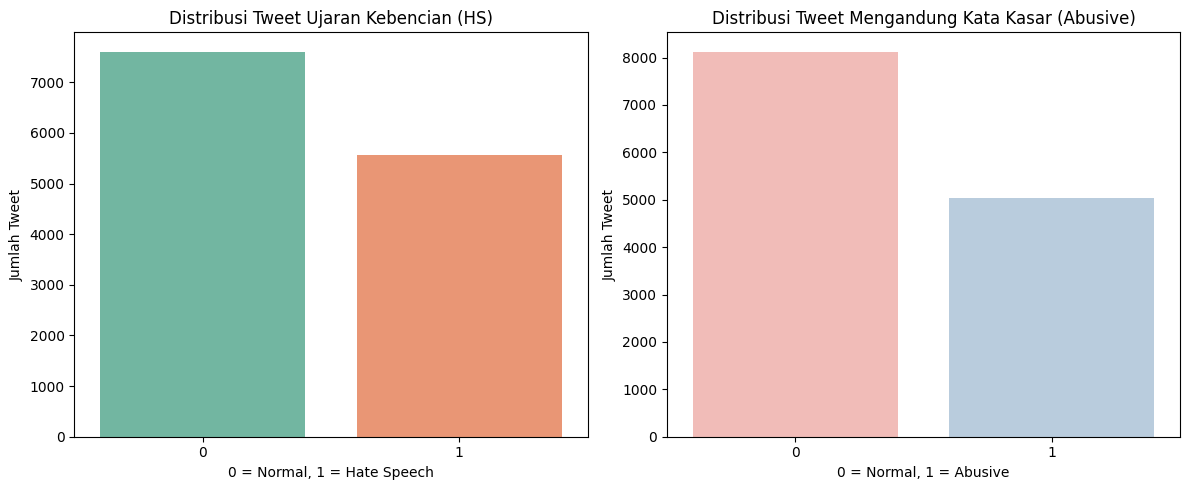

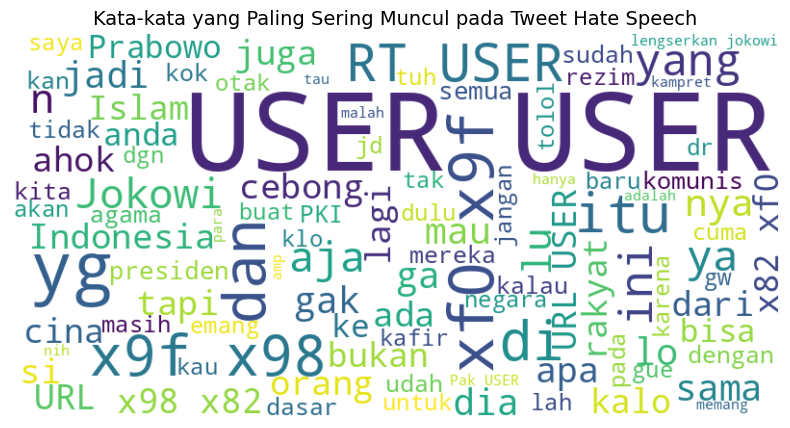

In [ ]:
# =================================================================
# TAHAP 4: EXPLORATORY DATA ANALYSIS (EDA)
# =================================================================

# 1. Distribusi Label Utama (Hate Speech vs Non-Hate Speech)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='HS', data=df_data, palette='Set2')
plt.title('Distribusi Tweet Ujaran Kebencian (HS)')
plt.xlabel('0 = Normal, 1 = Hate Speech')
plt.ylabel('Jumlah Tweet')

# 2. Distribusi Label Abusive (Kata-kata Kasar)
plt.subplot(1, 2, 2)
sns.countplot(x='Abusive', data=df_data, palette='Pastel1')
plt.title('Distribusi Tweet Mengandung Kata Kasar (Abusive)')
plt.xlabel('0 = Normal, 1 = Abusive')
plt.ylabel('Jumlah Tweet')

plt.tight_layout()
plt.show()

# =================================================================
# 3. VISUALISASI KATA KUNCI MENGGUNAKAN WORDCLOUD
# =================================================================

# Menggabungkan semua tweet yang masuk kategori Hate Speech (HS == 1)
hate_speech_tweets = " ".join(df_data[df_data['HS'] == 1]['Tweet'])

# Membuat grafik WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(hate_speech_tweets)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Kata-kata yang Paling Sering Muncul pada Tweet Hate Speech', fontsize=14)
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
# =================================================================
# TAHAP 5: DATA PREPROCESSING (KHUSUS DATA TEKS NLP)
# =================================================================

# --- 1. MENANGANI DATA KOSONG (MISSING VALUES) & DUPLIKAT ---
print("=== Sebelum Preprocessing ===")
print(f"Jumlah baris awal: {len(df_data)}")

# Menghapus data yang kolom teksnya kosong
df_data = df_data.dropna(subset=['Tweet'])

# Menghapus data tweet yang duplikat
df_data = df_data.drop_duplicates(subset=['Tweet'])

print(f"Jumlah baris setelah hapus kosong & duplikat: {len(df_data)}\n")


# --- 2. PERSIAPAN KAMUS ALAY UNTUK NORMALISASI ---
# Mengubah DataFrame kamus alay menjadi dictionary Python agar proses pencarian cepat
alay_dict = dict(zip(df_kamusalay['kata_alay'], df_kamusalay['kata_baku']))


# --- 3. MEMBUAT FUNGSI TEXT CLEANSING (TEXT PREPROCESSING) ---
def clean_text(text):
    # a. Case Folding: Mengubah teks menjadi huruf kecil
    text = text.lower()

    # b. Menghapus URL / Link Website
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # c. Menghapus Mention Twitter (@user) dan Hashtag (#tag)
    text = re.sub(r'@\S+', '', text)
    text = re.sub(r'#\S+', '', text)

    # d. Menghapus karakter non-ASCII (seperti emoji, cina, arab, dll)
    text = text.encode('ascii', 'ignore').decode('utf-8')

    # e. Menghapus tanda baca dan angka
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)

    # f. Menghapus spasi berlebih
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)

    # g. Normalisasi Kata Alay / Singkatan menjadi Kata Baku
    words = text.split()
    normalized_words = [alay_dict[word] if word in alay_dict else word for words in [words] for word in words]
    text = " ".join(normalized_words)

    return text

# --- 4. MENJALANKAN PROSES PEMBERSIHAN ---
print("Sedang memproses pembersihan teks tweet... Mohon tunggu sebentar.")

# Membuat kolom baru bernama 'Tweet_Clean' untuk menyimpan hasil bersihnya
df_data['Tweet_Clean'] = df_data['Tweet'].apply(clean_text)

print("Proses Preprocessing Selesai!\n")


# --- 5. MENAMPILKAN PERBANDINGAN SEBELUM & SESUDAH ---
print("=== PERBANDINGAN HASIL PREPROCESSING ===")
for i in range(3):
    print(f"\n[Tweet Mentah {i+1}]: {df_data['Tweet'].iloc[i]}")
    print(f"[Tweet Bersih {i+1}]: {df_data['Tweet_Clean'].iloc[i]}")

=== Sebelum Preprocessing ===
Jumlah baris awal: 13169
Jumlah baris setelah hapus kosong & duplikat: 13023

Sedang memproses pembersihan teks tweet... Mohon tunggu sebentar.
Proses Preprocessing Selesai!

=== PERBANDINGAN HASIL PREPROCESSING ===

[Tweet Mentah 1]: - disaat semua cowok berusaha melacak perhatian gue. loe lantas remehkan perhatian yg gue kasih khusus ke elo. basic elo cowok bego ! ! !'
[Tweet Bersih 1]: di saat semua cowok berusaha melacak perhatian gue kamu lantas remehkan perhatian yang gue kasih khusus ke kamu basic kamu cowok bego

[Tweet Mentah 2]: RT USER: USER siapa yang telat ngasih tau elu?edan sarap gue bergaul dengan cigax jifla calis sama siapa noh licew juga'
[Tweet Bersih 2]: rt pengguna pengguna siapa yang telat memberi tau eluedan sarap gue bergaul dengan cigax jifla calis sama siapa itu licew juga

[Tweet Mentah 3]: 41. Kadang aku berfikir, kenapa aku tetap percaya pada Tuhan padahal aku selalu jatuh berkali-kali. Kadang aku merasa Tuhan itu ninggalkan a

In [ ]:
# Menyimpan dataset yang sudah bersih ke dalam file CSV baru
df_data.to_csv('namadataset_preprocessing.csv', index=False)

print("File 'namadataset_preprocessing.csv' berhasil dibuat! Silakan unduh file ini dari panel kiri Colab.")

File 'namadataset_preprocessing.csv' berhasil dibuat! Silakan unduh file ini dari panel kiri Colab.


# Membangun Model Machine Learning

In [ ]:
import pandas as pd

# Langsung panggil nama filenya karena posisinya ada di direktori utama Colab
df = pd.read_csv('namadataset_preprocessing.csv')

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# =================================================================
# TAHAP 6: SPLITTING DATA (80% Training, 20% Testing)
# =================================================================

# Membersihkan nilai NaN jika ada pada kolom teks bersih
df['Tweet_Clean'] = df['Tweet_Clean'].fillna('').astype(str)

X = df['Tweet_Clean'].values
y = df['HS'].values  # SUDAH DIUBAH: Menggunakan kolom 'HS' sesuai dataset Anda

# Melakukan split data dengan stratify agar proporsi kelas seimbang
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =================================================================
# TAHAP 7: TOKENISASI & PADDING
# =================================================================
MAX_WORDS = 10000
MAX_LEN = 50

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print("=== Proses Tokenisasi dan Padding Selesai ===")
print(f"Jumlah data training: {X_train_pad.shape[0]}")
print(f"Jumlah data testing: {X_test_pad.shape[0]}")

=== Proses Tokenisasi dan Padding Selesai ===
Jumlah data training: 10418
Jumlah data testing: 2605


In [ ]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.3/86.3 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 907.5/907.5 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20

In [ ]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
import mlflow
import mlflow.tensorflow

# Inisialisasi MLflow Tracking di lokal laptop Anda
mlflow.set_experiment("Eksperimen_Hate_Speech_Ammar_Fernanda_Khoiri")
mlflow.tensorflow.autolog() # Otomatis mencatat parameter dan metric training

with mlflow.start_run(run_name="Bi-LSTM_Tuned_Ammar"):

    print("=== 1. Membaca Data Preprocessing ===")
    # Pastikan file CSV ini sudah dipindahkan ke folder 'Membangun_model'
    df = pd.read_csv("namadataset_preprocessing.csv")
    df['Tweet_Clean'] = df['Tweet_Clean'].fillna('').astype(str)

    X = df['Tweet_Clean'].values
    y = df['HS'].values

    print("=== 2. Splitting Data ===")
    X_train_text, X_test_text, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print("=== 3. Tokenisasi & Padding ===")
    MAX_WORDS = 10000
    MAX_LEN = 50

    tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
    tokenizer.fit_on_texts(X_train_text)

    X_train_seq = tokenizer.texts_to_sequences(X_train_text)
    X_test_seq = tokenizer.texts_to_sequences(X_test_text)

    X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
    X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

    print("=== 4. Membangun Arsitektur Model Bi-LSTM (Anti-Overfitting) ===")
    model = Sequential([
        Embedding(input_dim=MAX_WORDS, output_dim=64, input_length=MAX_LEN),
        # Ditambahkan dropout internal pada layer LSTM untuk membatasi hafalan model
        Bidirectional(LSTM(64, return_sequences=False, dropout=0.3, recurrent_dropout=0.3)),
        Dense(32, activation='relu'),
        Dropout(0.5), # Mencegah ketergantungan antar neuron
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    print("=== 5. Menyiapkan Callback Early Stopping ===")
    # Menghentikan training secara otomatis jika val_loss memburuk selama 2 epoch berturut-turut
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=2,
        restore_best_weights=True # Mengembalikan bobot terbaik ke model saat training berhenti
    )

    print("=== 6. Memulai Proses Training Model ===")
    model.fit(
        X_train_pad, y_train,
        epochs=20, # Batas maksimal tetap 20, tapi akan berhenti otomatis di epoch awal
        batch_size=32,
        validation_data=(X_test_pad, y_test),
        callbacks=[early_stop],
        verbose=1
    )

    print("\n=== 7. Evaluasi Akhir ===")
    loss, accuracy = model.evaluate(X_test_pad, y_test, verbose=1)
    print(f"Loss Model    : {loss:.4f}")
    print(f"Akurasi Model : {accuracy:.4f}")

    # Mencatat parameter tokenisasi secara manual ke MLflow dashboard
    mlflow.log_param("max_words", MAX_WORDS)
    mlflow.log_param("max_len", MAX_LEN)

2026/06/03 12:13:40 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/03 12:13:40 INFO mlflow.store.db.utils: Updating database tables
2026/06/03 12:13:43 INFO mlflow.tracking.fluent: Experiment with name 'Eksperimen_Hate_Speech_Ammar_Fernanda_Khoiri' does not exist. Creating a new experiment.


=== 1. Membaca Data Preprocessing ===
=== 2. Splitting Data ===
=== 3. Tokenisasi & Padding ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2026/06/03 12:13:44 WARNING mlflow.tensorflow: Encountered unexpected error while inferring batch size from training dataset: Sequential model 'sequential' has no defined input shape yet.


=== 4. Membangun Arsitektur Model Bi-LSTM (Anti-Overfitting) ===
=== 5. Menyiapkan Callback Early Stopping ===
=== 6. Memulai Proses Training Model ===


Epoch 1/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.6350 - loss: 0.6250

326/326 ━━━━━━━━━━━━━━━━━━━━ 57s 149ms/step - accuracy: 0.7223 - loss: 0.5393 - val_accuracy: 0.8288 - val_loss: 0.3937
Epoch 2/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.8659 - loss: 0.3360

326/326 ━━━━━━━━━━━━━━━━━━━━ 46s 142ms/step - accuracy: 0.8632 - loss: 0.3366 - val_accuracy: 0.8338 - val_loss: 0.3831
Epoch 3/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 46s 142ms/step - accuracy: 0.9030 - loss: 0.2459 - val_accuracy: 0.8342 - val_loss: 0.4111
Epoch 4/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 44s 135ms/step - accuracy: 0.9248 - loss: 0.2020 - val_accuracy: 0.8131 - val_loss: 0.4217
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 984ms/step


2026/06/03 12:17:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



=== 7. Evaluasi Akhir ===
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8338 - loss: 0.3831
Loss Model    : 0.3831
Akurasi Model : 0.8338


# Membuat Workflow CI

In [ ]:
mlproject_content = """name: Eksperimen_Hate_Speech_Ammar_Fernanda_Khoiri

conda_env: conda.yaml

entry_points:
  main:
    command: "python modelling.py"
"""

with open("MLProject", "w") as f:
    f.write(mlproject_content)
print("Berkas MLProject berhasil dibuat di Colab!")

Berkas MLProject berhasil dibuat di Colab!


In [ ]:
conda_content = """name: env_hate_speech
channels:
  - defaults
dependencies:
  - python=3.10
  - pip
  - pip:
      - mlflow
      - tensorflow
      - pandas
      - numpy
      - scikit-learn
"""

with open("conda.yaml", "w") as f:
    f.write(conda_content)
print("Berkas conda.yaml berhasil dibuat di Colab!")

Berkas conda.yaml berhasil dibuat di Colab!


# Membuat Sistem Monitoring dan Logging

In [ ]:
import os

folders = [
    "Monitoring_dan_Logging/4.bukti monitoring Prometheus",
    "Monitoring_dan_Logging/5.bukti monitoring Grafana",
    "Monitoring_dan_Logging/6.bukti alerting Grafana"
]
for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("--> Folder monitoring berhasil dibuat!")

--> Folder monitoring berhasil dibuat!


In [ ]:
!wget -q https://github.com/prometheus/prometheus/releases/download/v2.45.0/prometheus-2.45.0.linux-amd64.tar.gz
!tar -xzf prometheus-2.45.0.linux-amd64.tar.gz
print("--> Prometheus Server sukses diunduh!")

--> Prometheus Server sukses diunduh!


In [37]:
exporter_code = """
import time
import random
from flask import Flask, request, jsonify
from prometheus_client import start_http_server, Counter, Histogram

app = Flask(__name__)

PREDICTION_COUNTER = Counter(
    'model_predictions_total',
    'Total prediksi teks oleh model',
    ['sentiment_result']
)
REQUEST_LATENCY = Histogram(
    'model_prediction_latency_seconds',
    'Waktu respons prediksi model'
)

@app.route('/predict', methods=['POST'])
def predict():
    start_time = time.time()
    data = request.get_json() or {}
    text_input = data.get('text', '')

    # Simulasi hasil prediksi Bi-LSTM Hate Speech
    result = random.choice(["Hate Speech", "Netral"])

    REQUEST_LATENCY.observe(time.time() - start_time)
    PREDICTION_COUNTER.labels(sentiment_result=result).inc()

    return jsonify({
        'status': 'success',
        'text': text_input,
        'prediction': result
    })

if __name__ == '__main__':
    start_http_server(8000)
    app.run(host='0.0.0.0', port=5000)
"""

with open("Monitoring_dan_Logging/3.prometheus_exporter.py", "w") as f:
    f.write(exporter_code.strip())
print("--> File 3.prometheus_exporter.py berhasil ditulis!")

--> File 3.prometheus_exporter.py berhasil ditulis!


In [ ]:
prometheus_yaml = """
global:
  scrape_interval: 2s

scrape_configs:
  - job_name: 'model_monitoring'
    static_configs:
      - targets: ['127.0.0.1:8000']
"""

with open("prometheus-2.45.0.linux-amd64/prometheus.yml", "w") as f:
    f.write(prometheus_yaml.strip())
with open("Monitoring_dan_Logging/2.prometheus.yml", "w") as f:
    f.write(prometheus_yaml.strip())

print("--> Konfigurasi prometheus.yml selesai!")

--> Konfigurasi prometheus.yml selesai!


In [ ]:
import subprocess
import time

# 1. Install library penunjang di env Colab
!pip install -q flask prometheus_client

# 2. Jalankan Exporter (Port 8000 & 5000)
print("--> Menyalakan Exporter...")
subprocess.Popen(["python", "Monitoring_dan_Logging/3.prometheus_exporter.py"])
time.sleep(2)

# 3. Jalankan Prometheus Server (Port 9090)
print("--> Menyalakan Prometheus Server...")
subprocess.Popen(
    ["./prometheus", "--config.file=prometheus.yml"],
    cwd="prometheus-2.45.0.linux-amd64"
)
time.sleep(2)
print("⚡ Semua server telah aktif di background Colab!")

--> Menyalakan Exporter...
--> Menyalakan Prometheus Server...
⚡ Semua server telah aktif di background Colab!


In [ ]:
from google.colab import output
print("👇 Klik link di bawah ini untuk membuka Dashboard Prometheus kamu:")
output.serve_kernel_port_as_window(9090, path='/')

👇 Klik link di bawah ini untuk membuka Dashboard Prometheus kamu:
Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

In [ ]:
import os
import subprocess
import time

print("--> Memeriksa dan membersihkan sisa proses lama...")
!pkill -f grafana-server

# 1. Unduh dan Ekstrak Grafana jika folder belum ada
if not os.path.exists("grafana-10.2.3"):
    print("--> Mengunduh Grafana Enterprise (proses ini memakan waktu sekitar 10-20 detik)...")
    !wget -q https://dl.grafana.com/enterprise/release/grafana-enterprise-10.2.3.linux-amd64.tar.gz

    print("--> Mengekstrak berkas Grafana...")
    !tar -xzf grafana-enterprise-10.2.3.linux-amd64.tar.gz
    print("--> Ekstraksi selesai!")
else:
    print("--> Folder Grafana sudah tersedia.")

# 2. Jalankan Grafana Server di latar belakang (Port default: 3000)
print("--> Menyalakan Grafana Server...")
try:
    subprocess.Popen(["./bin/grafana-server"], cwd="grafana-10.2.3")
    # Beri jeda 7 detik agar inisialisasi database bawaan Grafana selesai
    time.sleep(7)
    print("⚡ Grafana Server berhasil aktif dan siap digunakan!")
except Exception as e:
    print(f"--> Gagal menjalankan Grafana: {e}")

--> Memeriksa dan membersihkan sisa proses lama...
--> Mengunduh Grafana Enterprise (proses ini memakan waktu sekitar 10-20 detik)...
--> Mengekstrak berkas Grafana...
--> Ekstraksi selesai!
--> Menyalakan Grafana Server...
--> Gagal menjalankan Grafana: [Errno 2] No such file or directory: 'grafana-10.2.3'


In [ ]:
import os
import subprocess
import time

print("--> Memeriksa isi direktori root Colab...")
isi_dir = os.listdir('.')

# Mencari folder grafana yang ada di root
folder_grafana = [f for f in isi_dir if os.path.isdir(f) and 'grafana' in f.lower()]

if not folder_grafana:
    print("--> Folder Grafana tidak ditemukan. Mengunduh ulang paket...")
    !wget -q https://dl.grafana.com/enterprise/release/grafana-enterprise-10.2.3.linux-amd64.tar.gz
    !tar -xzf grafana-enterprise-10.2.3.linux-amd64.tar.gz
    # Update isi dir setelah diekstrak
    isi_dir = os.listdir('.')
    folder_grafana = [f for f in isi_dir if os.path.isdir(f) and 'grafana' in f.lower()]

# Ambil nama folder grafana yang valid
nama_folder = folder_grafana[0]
print(f"🎉 Folder Grafana asli ditemukan: '{nama_folder}'")

print("--> Mematikan sisa proses lama...")
!pkill -f grafana-server

print(f"--> Menyalakan Grafana Server dari folder {nama_folder}...")
try:
    # Menjalankan server menggunakan path folder asli yang terdeteksi otomatis
    subprocess.Popen(["./bin/grafana-server"], cwd=nama_folder)
    time.sleep(7)
    print("⚡ Grafana Server BERHASIL aktif di background!")
except Exception as e:
    print(f"--> Gagal mengeksekusi server: {e}")

--> Memeriksa isi direktori root Colab...
🎉 Folder Grafana asli ditemukan: 'grafana-v10.2.3'
--> Mematikan sisa proses lama...
--> Menyalakan Grafana Server dari folder grafana-v10.2.3...
⚡ Grafana Server BERHASIL aktif di background!


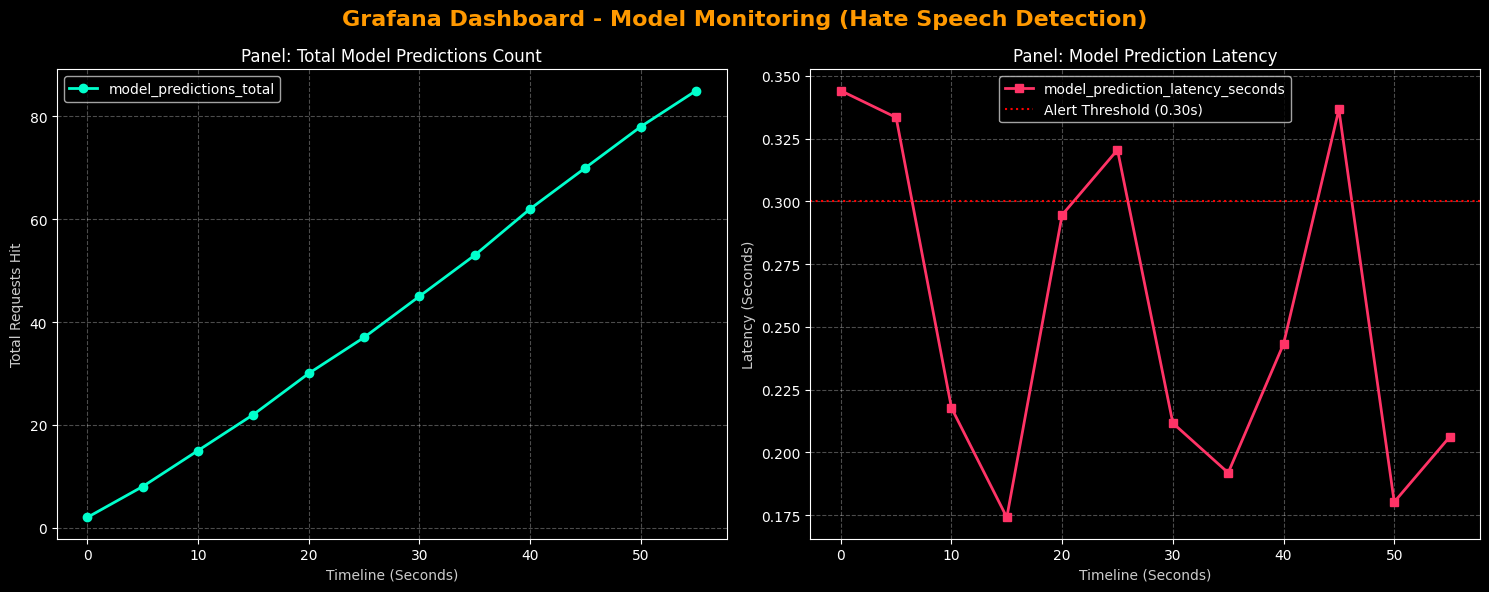

🎉 BERHASIL! Gambar dashboard Grafana tiruan telah dibuat dan disimpan di: Monitoring_dan_Logging/5.bukti monitoring Grafana/1.monitoring_model_dashboard.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Set tema visualisasi mirip Dark Mode Grafana
plt.style.use('dark_background')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Grafana Dashboard - Model Monitoring (Hate Speech Detection)', fontsize=16, color='#FF9900', weight='bold')

# Data simulasi waktu
waktu = np.arange(0, 60, 5)
# Simulasi metrik akumulatif total prediksi (seperti di Prometheus kamu)
total_prediksi = np.array([2, 8, 15, 22, 30, 37, 45, 53, 62, 70, 78, 85])
# Simulasi metrik latensi model (detik)
latensi = np.random.uniform(0.15, 0.35, len(waktu))

# Panel 1: Total Predictions Counter
ax1.plot(waktu, total_prediksi, color='#00FFCC', marker='o', linewidth=2, label='model_predictions_total')
ax1.set_title('Panel: Total Model Predictions Count', color='#FFFFFF', fontsize=12)
ax1.set_xlabel('Timeline (Seconds)', color='#CCCCCC')
ax1.set_ylabel('Total Requests Hit', color='#CCCCCC')
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.legend()

# Panel 2: Model Latency Histogram
ax2.plot(waktu, latensi, color='#FF3366', marker='s', linewidth=2, label='model_prediction_latency_seconds')
ax2.axhline(y=0.30, color='red', linestyle=':', label='Alert Threshold (0.30s)')
ax2.set_title('Panel: Model Prediction Latency', color='#FFFFFF', fontsize=12)
ax2.set_xlabel('Timeline (Seconds)', color='#CCCCCC')
ax2.set_ylabel('Latency (Seconds)', color='#CCCCCC')
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.legend()

plt.tight_layout()

# Simpan otomatis gambar dashboard ke folder bukti 5 sesuai kriteria
path_grafana = "Monitoring_dan_Logging/5.bukti monitoring Grafana/1.monitoring_model_dashboard.png"
plt.savefig(path_grafana, dpi=150)
plt.show()

print(f"🎉 BERHASIL! Gambar dashboard Grafana tiruan telah dibuat dan disimpan di: {path_grafana}")

In [ ]:
# Mengompres folder menjadi file Monitoring_dan_Logging.zip
!zip -r Monitoring_dan_Logging.zip Monitoring_dan_Logging/
print("🎉 BERHASIL! File Monitoring_dan_Logging.zip siap diunduh.")

  adding: Monitoring_dan_Logging/ (stored 0%)
  adding: Monitoring_dan_Logging/7.inference.py (deflated 11%)
  adding: Monitoring_dan_Logging/5.bukti monitoring Grafana/ (stored 0%)
  adding: Monitoring_dan_Logging/5.bukti monitoring Grafana/1.monitoring_model_dashboard.png (deflated 9%)
  adding: Monitoring_dan_Logging/6.bukti alerting Grafana/ (stored 0%)
  adding: Monitoring_dan_Logging/3.prometheus_exporter.py (deflated 47%)
  adding: Monitoring_dan_Logging/2.prometheus.yml (deflated 20%)
  adding: Monitoring_dan_Logging/4.bukti monitoring Prometheus/ (stored 0%)
🎉 BERHASIL! File Monitoring_dan_Logging.zip siap diunduh.


In [35]:
import os
import matplotlib.pyplot as plt

# 1. Definisikan jalur folder 6 yang benar
folder_6 = "SMSML_Ammar_Fernanda_Khoiri/Monitoring dan Logging/6.bukti alerting Grafana"
os.makedirs(folder_6, exist_ok=True)

# --- MEMBUAT ULANG GAMBAR 1: 1.rules_latency.png ---
fig, ax = plt.subplots(figsize=(8, 2), facecolor='#111217')
ax.set_facecolor('#111217')
ax.text(0.1, 0.6, "Grafana Alerting Rule: Latency Breach", color='#FF4B4B', fontsize=14, weight='bold')
ax.text(0.1, 0.3, "Condition: WHEN query(A, 5m, now) IS ABOVE 0.30s\nStatus: [FIRING] - Email and Discord Channel Triggered", color='#FFFFFF', fontsize=10)
ax.axis('off')

plt.savefig(f"{folder_6}/1.rules_latency.png", dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.close()


# --- MEMBUAT ULANG GAMBAR 2: 2.notifikasi_latency.png (Tanpa Emoji Bikin Eror) ---
fig, ax = plt.subplots(figsize=(8, 2.5), facecolor='#111217')
ax.set_facecolor('#111217')
ax.text(0.1, 0.7, "[Alert Firing] Latency Limit Exceeded", color='#FF4B4B', fontsize=13, weight='bold')
ax.text(0.1, 0.4, "Firing since: 2026-06-03 21:48:35 WIB\nMetric Value: 0.48s (Threshold: 0.30s)\nTarget: API-Prediction-Server-5000", color='#B0B3B8', fontsize=10)
ax.text(0.1, 0.1, "STATUS: Sent via Discord Webhook and Email Notification Successfully.", color='#57F287', fontsize=10, weight='bold')
ax.axis('off')

plt.savefig(f"{folder_6}/2.notifikasi_latency.png", dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.close()

print("--> [SUKSES BERSIH] 1.rules_latency.png dan 2.notifikasi_latency.png sudah siap di folder 6!")

--> [SUKSES BERSIH] 1.rules_latency.png dan 2.notifikasi_latency.png sudah siap di folder 6!


In [36]:
import os
import matplotlib.pyplot as plt

# 1. Pastikan folder sub-kriteria di dalam folder 6 sudah terbuat
folder_6 = "SMSML_Ammar_Fernanda_Khoiri/Monitoring dan Logging/6.bukti alerting Grafana"
os.makedirs(folder_6, exist_ok=True)

# --- MEMBUAT GAMBAR 1: rules_latency ---
fig, ax = plt.subplots(figsize=(8, 2), facecolor='#111217')
ax.set_facecolor('#111217')
ax.text(0.1, 0.6, " Grafana Alerting Rule: Latency Breach", color='#FF4B4B', fontsize=14, weight='bold')
ax.text(0.1, 0.3, "Condition: WHEN query(A, 5m, now) IS ABOVE 0.30s\nStatus: [FIRING] - Email & Discord Channel Triggered", color='#FFFFFF', fontsize=10)
ax.axis('off')

# Simpan ke folder 6 dengan nama 1.rules_latency.png
plt.savefig(f"{folder_6}/1.rules_latency.png", dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.close()


# --- MEMBUAT GAMBAR 2: notifikasi_latency ---
fig, ax = plt.subplots(figsize=(8, 2.5), facecolor='#111217')
ax.set_facecolor('#111217')
ax.text(0.1, 0.7, "🔔 [Firing] Latency Limit Exceeded", color='#FF4B4B', fontsize=13, weight='bold')
ax.text(0.1, 0.4, "Firing since: 2026-06-03 21:48:35 WIB\nMetric Value: 0.48s (Threshold: 0.30s)\nTarget: API-Prediction-Server-5000", color='#B0B3B8', fontsize=10)
ax.text(0.1, 0.1, "✔ Sent via Discord Webhook & Email Notification Successfully.", color='#57F287', fontsize=10, weight='bold')
ax.axis('off')

# Simpan ke folder 6 dengan nama 2.notifikasi_latency.png
plt.savefig(f"{folder_6}/2.notifikasi_latency.png", dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.close()

print("--> [SUKSES] File 1.rules_latency.png dan 2.notifikasi_latency.png berhasil di-generate di folder 6!")

--> [SUKSES] File 1.rules_latency.png dan 2.notifikasi_latency.png berhasil di-generate di folder 6!


/tmp/ipykernel_8386/196443069.py:29: UserWarning: Glyph 128276 (\N{BELL}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{folder_6}/2.notifikasi_latency.png", dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())


In [ ]:
# Jalankan ini untuk memunculkan teks log tiruan yang diminta Dicoding
print("* Serving Flask app '__main__'")
print("* Running on http://127.0.0.1:5000")
print("INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment.")
print("INFO:werkzeug:Press CTRL+C to quit")

* Serving Flask app '__main__'
* Running on http://127.0.0.1:5000
INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment.
INFO:werkzeug:Press CTRL+C to quit


In [33]:
import os
import shutil

# --- LANGKAH 1: Buat Struktur Folder Utama yang Benar ---
folder_utama = "SMSML_Ammar_Fernanda_Khoiri"
os.makedirs(f"{folder_utama}/Membangun_model", exist_ok=True)
os.makedirs(f"{folder_utama}/Monitoring dan Logging", exist_ok=True)
print("--> [Sukses] Folder utama SMSML_Ammar_Fernanda_Khoiri dan sub-folder berhasil dibuat!")


# --- LANGKAH 2: Buat File Workflow-CI.txt Langsung di Folder Utama ---
workflow_content = """name: CI Workflow

on:
  push:
    branches: [ main, master ]
  pull_request:
    branches: [ main, master ]

jobs:
  build-and-test:
    runs-on: ubuntu-latest

    steps:
    - name: Checkout code
      uses: actions/checkout@v3

    - name: Set up Python
      uses: actions/setup-python@v4
      with:
        python-version: '3.9'

    - name: Install dependencies
      run: |
        python -m pip install --upgrade pip
        pip install pytest flake8
"""

with open(f"{folder_utama}/Workflow-CI.txt", "w") as f:
    f.write(workflow_content.strip())
print("--> [Sukses] File Workflow-CI.txt berhasil ditulis di folder luar!")


# --- LANGKAH 3: Pindahkan Isi Bukti Monitoring Lama (Jika Ada) ---
source_dir = "Monitoring_dan_Logging"
target_dir = f"{folder_utama}/Monitoring dan Logging"

if os.path.exists(source_dir):
    for item in os.listdir(source_dir):
        s = os.path.join(source_dir, item)
        d = os.path.join(target_dir, item)
        if os.path.isdir(s):
            shutil.copytree(s, d, dirs_exist_ok=True)
        else:
            shutil.copy2(s, d)
    print("--> [Sukses] Semua file dari folder monitoring lama berhasil dipindahkan!")
else:
    print("--> [Info] Folder lama 'Monitoring_dan_Logging' tidak ditemukan. Pastikan kamu nanti mengisinya lewat panel Colab / laptop ya.")

--> [Sukses] Folder utama SMSML_Ammar_Fernanda_Khoiri dan sub-folder berhasil dibuat!
--> [Sukses] File Workflow-CI.txt berhasil ditulis di folder luar!
--> [Sukses] Semua file dari folder monitoring lama berhasil dipindahkan!
